## Modelos de Machine Learning: XGBoost, Sistema de Predicción Energética en Barcelona


> Hermano del notebook 06 (LightGBM). El objetivo es el mismo: comprobar si los modelos de árboles
> capturan relaciones no lineales e interacciones, ahora con **XGBoost**.

### Principio de comparación justa

- el mismo split temporal (train 2019–2024 · validación ene–sep 2025 · test oct–nov 2025 intacto)
- las mismas métricas (R² primaria; MAE, RMSE, MAPE)
- los mismos horizontes de backtesting (24h, 48h, 72h)
- el mismo arnés (skforecast: ForecasterRecursiveMultiSeries + backtesting walk-forward, refit=False)

> La única diferencia de fondo frente al 06 es el regresor interno (`XGBRegressor` en vez de
> `LGBMRegressor`). Todo lo demás se mantiene para que la comparación XGBoost vs LightGBM dependa
> solo del algoritmo, no del montaje.


## Librerías

In [ ]:
import os
os.environ['TQDM_DISABLE'] = '1'   # mata barras tqdm/ipywidgets (bug de render de VS Code)
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
import warnings, time
import skforecast; print(skforecast.__version__)
from xgboost import XGBRegressor 
import shap
from skforecast.recursive import ForecasterRecursiveMultiSeries, ForecasterEquivalentDate
from skforecast.preprocessing import RollingFeatures
from skforecast.model_selection import (
    TimeSeriesFold,
    backtesting_forecaster_multiseries,
)
from skforecast.exceptions import MissingValuesWarning
warnings.simplefilter('ignore', category=MissingValuesWarning)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


warnings.filterwarnings('ignore')

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D3D3'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta
C1 = '#264653'; C2 = '#2A9D8F'; C3 = '#E9C46A'
C4 = '#F4A261'; C5 = '#E76F51'; C6 = '#A8DADC'
TITULO = '#1B3A5C'; SUBTITULO = '#C0392B'

start_time = time.time()

0.22.0


---
## Carga de datos

In [ ]:
client = MongoClient('mongodb://mongo:27017/')
db     = client['tfm_energy']

docs = list(db['dataset_ml'].find({}, {'_id': 0}))
df_ml   = pl.DataFrame(docs, infer_schema_length=None)

print(f"Shape: {df_ml.shape}")
print(f"Desde: {df_ml['datetime'].min()}  Hasta: {df_ml['datetime'].max()}")
print(f"Codigos postales: {df_ml['cod_postal'].n_unique()}")
print(f"Columnas ({len(df_ml.columns)}):")
print(sorted(df_ml.columns))

Shape: (424368, 33)
Desde: 2019-01-01 00:00:00  Hasta: 2025-11-30 18:00:00
Codigos postales: 42
Columnas (33):
['CDD', 'HDD', 'anio', 'cdd_roll_3d', 'cod_postal', 'datetime', 'dia_semana', 'es_festivo', 'es_finde', 'hora', 'hora_x_finde', 'humedad_mean', 'irradiancia_mean', 'is_covid', 'lag_1', 'lag_2', 'lag_28', 'lag_3', 'lag_4', 'lag_56', 'lst_celsius', 'lst_nublado', 'mes', 'mwh_total', 'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp', 'precipitacion_llueve', 'rolling_mean_7d', 'rolling_std_7d', 'semana_anio', 'temp_mean', 'viento_mean']


---
# <font color='#1B3A5C'>  **1. Configuración del Experimento** </font>

> mismos cortes temporales y horizontes que SARIMA/SARIMAX (05) y LightGBM (06) para que la
> comparación baseline vs. ML sea justa. El conjunto de *test* (oct–nov 2025) queda intacto.

In [ ]:
INI       = '2019-01-01'             # historico completo
FIN_TRAIN = '2024-12-31 18:00:00'    # fin de train
FIN_VAL   = '2025-09-30 18:00:00'    # fin de validacion (2025-01 -> 2025-09)

HORIZONTES = {'24h': 4, '48h': 8, '72h': 12}

TARGET = 'mwh_total'
CPS_SUCIOS = ['08011','08009','08007','08013','08010','08006','08005',
              '08019','08008','08036','08026','08037']
CPS_TODOS = [cp for cp in sorted(df_ml['cod_postal'].unique().to_list()) if cp not in CPS_SUCIOS]

print(f"Train : {INI} -> {FIN_TRAIN}")
print(f"Val   : 2025-01-01 -> {FIN_VAL}")
print(f"Test  : 2025-10-01 -> {df_ml['datetime'].max()}  (intacto)")
print(f"Horizontes: {HORIZONTES}")
print(f"Target: {TARGET} | CPs: {len(CPS_TODOS)}")

Train : 2019-01-01 -> 2024-12-31 18:00:00
Val   : 2025-01-01 -> 2025-09-30 18:00:00
Test  : 2025-10-01 -> 2025-11-30 18:00:00  (intacto)
Horizontes: {'24h': 4, '48h': 8, '72h': 12}
Target: mwh_total | CPs: 30


### <font color='#C0392B'><b>1.1 Los cuatro roles de las variables</b></font>

> Hay que asignar a cada variable su papel para skforecast.

 - Identificadores datetime, cod_postal estructuran serie y tiempo.
 - Target mwh_total.
 - Autorregresivas lags, rollings, se descartan; skforecast las regenera sin leakage.
 - Exógenas como clima, calendario y perfil sectorial los regresores externos que sí entran.

In [ ]:
LAGS = [1, 2, 3, 4, 28]
AUTOREG = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28', 'lag_56', 'rolling_mean_7d', 'rolling_std_7d']  # lag_56: precalculado en el 04, se excluye y skforecast lo regenera
NO_EXOG = ['datetime', 'cod_postal', TARGET] + AUTOREG
EXOG = [c for c in df_ml.columns if c not in NO_EXOG]

### <font color='#C0392B'><b>1.2 Construcción de las series multi-series</b></font>

> ForecasterRecursiveMultiSeries no recibe la tabla plana, sino las 30 series agrupadas por código postal.

 - series y exog serán un diccionario por cada cosa.
 - Cada serie se reindexa a frecuencia de 6h (skforecast lo exige).
 - NaN residuales se mantienen, XGBoost los gestiona de forma nativa (igual que LightGBM), ventaja frente a SARIMAX.

In [ ]:
series = {}   # {cod_postal: pd.Series  (mwh_total, index 6h)}
exog   = {}   # {cod_postal: pd.DataFrame (EXOG, index 6h)}

for cp in CPS_TODOS:
    # Solo filas de ese barrio a pandas, la fecha es indice y marca frecuencia a 6h
    g = (df_ml.filter(pl.col('cod_postal') == cp)
              .sort('datetime')
              .to_pandas()
              .set_index('datetime'))
    g.index = pd.DatetimeIndex(g.index)
    g = g.asfreq('6h')

    # sanear exogenas booleanas para que funcione bien en los modelos de ML
    ex = g[EXOG].copy()
    bool_cols = ex.select_dtypes('bool').columns
    ex[bool_cols] = ex[bool_cols].astype('int8')

    series[cp] = g[TARGET]
    exog[cp]   = ex

# Comprobacion rapida
cp0 = CPS_TODOS[0]
print(f"Series: {len(series)} CPs")
print(f"{cp0}: {len(series[cp0])} bloques | exog {exog[cp0].shape} | "
      f"NaN exog: {int(exog[cp0].isna().sum().sum())}")
print("Columnas exog:", list(exog[cp0].columns))

print(series[cp0].head())
print(exog[cp0].head())

Series: 30 CPs
08001: 10104 bloques | exog (10104, 22) | NaN exog: 9017
Columnas exog: ['lst_celsius', 'temp_mean', 'humedad_mean', 'viento_mean', 'irradiancia_mean', 'es_festivo', 'hora', 'dia_semana', 'mes', 'anio', 'semana_anio', 'es_finde', 'HDD', 'CDD', 'lst_nublado', 'precipitacion_llueve', 'cdd_roll_3d', 'hora_x_finde', 'is_covid', 'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp']
datetime
2019-01-01 00:00:00     68681.0
2019-01-01 06:00:00     84009.0
2019-01-01 12:00:00    101500.0
2019-01-01 18:00:00    105428.0
2019-01-02 00:00:00     64121.0
Freq: 6h, Name: mwh_total, dtype: float64
                     lst_celsius  temp_mean  humedad_mean  viento_mean  \
datetime                                                                 
2019-01-01 00:00:00        12.57   9.883333     59.166667     0.466667   
2019-01-01 06:00:00        12.57  12.775000     61.750000     0.550000   
2019-01-01 12:00:00        12.57  14.650000     75.000000     1.666667   
2019-01-01 18:00

> El resultado son dos diccionarios con los CP de key y sus respectivas variables de value.

---
# <font color='#1B3A5C'>  **2. Modelo base: XGBoost multi-series** </font>

> Primer modelo con hiperparámetros por defecto, para tener una referencia antes de optimizar.
- Un único modelo que aprende de los 30 CPs a la vez.
- RollingFeatures genera el rolling_mean y std de 7 días del feature engineering.

In [ ]:
rolling = RollingFeatures(stats=['mean', 'std'], window_sizes=28)   # 28 bloques = 7 dias

#  XGBoost necesita enable_categorical=True para digerir la columna de nivel (cod_postal),
# que skforecast crea como 'category' con encoding='ordinal_category'. LightGBM lo hacia solo;
# es el unico ajuste de API frente al 06. (Si diera problemas, alternativa: encoding='ordinal'.)
forecaster = ForecasterRecursiveMultiSeries(
    estimator       = XGBRegressor(random_state=12, verbosity=0, enable_categorical=True),
    lags            = LAGS,
    window_features = rolling,
    encoding        = 'ordinal_category',
)
forecaster

============================== 
ForecasterRecursiveMultiSeries 
============================== 
Estimator: XGBRegressor 
Lags: [ 1  2  3  4 28] 
Window features: ['roll_mean_28', 'roll_std_28'] 
Window size: 28 
Series encoding: ordinal_category 
Series names (levels): None 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for series: None 
Transformer for exog: None 
Weight function included: False 
Series weights: None 
Differentiation order: None 
Drop NaN from series: False 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': True, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': None, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': None, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 12, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': None, 'tree_method': None, 'validate_parameters': None,
    'verbosity': 0} 
fit_kwargs: {} 
Creation date: 2026-06-12 16:11:05 
Last fit date: None 
Skforecast version: 0.22.0 
Python version: 3.11.15 
Forecaster id: None

In [ ]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    denom = np.where(y_true == 0, np.nan, y_true)
    return {
        'r2'   : r2_score(y_true, y_pred),
        'mae'  : mean_absolute_error(y_true, y_pred),
        'rmse' : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mape' : float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100),
        'wmape': float(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100),  # ponderado por volumen
    }

> **Funciones de evaluación reutilizables.** `backtest_periodo` es el único motor de backtest (walk-forward a 72h): se usa igual para validación y para test, solo cambia hasta dónde se entrena. `r2_mediano` resume sus predicciones en el R² mediano entre barrios.

In [ ]:
# Motor unico de evaluacion: backtest walk-forward a 72h, entrenando hasta `fin_entreno`.
# Se reutiliza igual para validacion y test; solo cambia hasta donde se entrena.
# suppress_warnings=True calla los MissingValuesWarning de skforecast (lst_celsius con nulos por nubes,
# tolerados de forma nativa por XGBoost). Es la via oficial de skforecast (el filtro global no basta
# porque la funcion resetea los filtros por dentro).
def backtest_periodo(forecaster, series_d, exog_d, fin_entreno, steps=12):
    idx = len(series_d[CPS_TODOS[0]].loc[:fin_entreno])
    cv  = TimeSeriesFold(steps=steps, initial_train_size=idx, refit=False)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _, pred = backtesting_forecaster_multiseries(
            forecaster, series=series_d, exog=exog_d, cv=cv,
            metric='mean_absolute_error', add_aggregated_metric=False,
            verbose=False, show_progress=False, suppress_warnings=True)
    return pred

# R2 mediano entre CPs limpios, a partir de las predicciones de un backtest.
def r2_mediano(pred, series_ref, excluir=()):
    rs = []
    for cp in sorted(pred['level'].unique()):
        if cp in excluir:
            continue
        p = pred.loc[pred['level'] == cp, 'pred'].sort_index()
        y = series_ref[cp].reindex(p.index)
        rs.append(metricas(y.values, p.values)['r2'])
    return float(np.median(rs))


### <font color='#C0392B'><b>2.1 Backtest en validación (modelo base, ene–sep 2025)</b></font>

In [ ]:
series_trval = {cp: s.loc[:FIN_VAL] for cp, s in series.items()}
exog_trval   = {cp: e.loc[:FIN_VAL] for cp, e in exog.items()}

# entrena -> 2024, evalua validacion 2025 (walk-forward 72h)
predicciones = backtest_periodo(forecaster, series_trval, exog_trval, fin_entreno=FIN_TRAIN)

print("predicciones:", predicciones.shape)
print(predicciones.head())


predicciones: (32760, 3)
            level  fold           pred
2025-01-01  08001     0   60810.417969
2025-01-01  08002     0   54712.269531
2025-01-01  08003     0   98488.000000
2025-01-01  08004     0  100086.367188
2025-01-01  08012     0   49522.855469


### <font color="#C0392B"><b>2.2 Revisión de resultados (función reutilizable)</b></font>

> `revisar_resultados()` reúne en una sola llamada toda la diagnosis del modelo desde su backtest:
> métricas por CP (R² primaria), R² por barrio, predicho vs real, error por horizonte, error por
> hora/día, curva train vs val, importancia nativa y SHAP. Es la misma función del 06, adaptada a
> la API de XGBoost (curva de entrenamiento y SHAP).

In [ ]:
def revisar_resultados(predicciones, series_trval, forecaster, exog_trval,
                       nombre='XGBoost', excluir=(),
                       cps_demo=('08002', '08028', '08039'),
                       ventana=('2025-03-01', '2025-03-31'),
                       shap_on=True, shap_sample=3000):
    """Dashboard de revision de un modelo desde su backtest. Devuelve ml_val."""
    cps = sorted(predicciones['level'].unique())

    # ---------- calculos ----------
    # metricas por CP
    filas = []
    for cp in cps:
        p = predicciones.loc[predicciones['level'] == cp, 'pred'].sort_index()
        y = series_trval[cp].reindex(p.index)
        m = metricas(y.values, p.values); m['cp'] = cp; filas.append(m)
    ml_val = pd.DataFrame(filas)
    val = ml_val[~ml_val['cp'].isin(excluir)]

    # error por horizonte
    err = []
    for cp in cps:
        if cp in excluir:
            continue
        sub = predicciones[predicciones['level'] == cp].sort_index().copy()
        sub['ae']   = np.abs(series_trval[cp].reindex(sub.index).values - sub['pred'].values)
        sub['step'] = sub.groupby('fold').cumcount() + 1
        err.append(sub[['step', 'ae']])
    curva = pd.concat(err).groupby('step')['ae'].mean()

    # error por hora / dia
    tt = []
    for cp in cps:
        if cp in excluir:
            continue
        sub = predicciones[predicciones['level'] == cp].sort_index()
        tt.append(pd.DataFrame({'ae': np.abs(series_trval[cp].reindex(sub.index).values - sub['pred'].values)}, index=sub.index))
    tt = pd.concat(tt); tt['hora'] = tt.index.hour; tt['dia'] = tt.index.dayofweek

    # curva train/val + importancia (reentrena un XGB con los params del forecaster)
    out = forecaster.create_train_X_y(series=series_trval, exog=exog_trval)
    X_all, y_all = out[0], out[1]
    # la columna de nivel viene como 'category'; para el XGB de diagnostico la pasamos a codigos
    # enteros (evita depender de enable_categorical en SHAP y en la curva). Es solo diagnostico.
    X_all = X_all.copy()
    for c in X_all.select_dtypes('category').columns:
        X_all[c] = X_all[c].cat.codes
    mtr = X_all.index <= FIN_TRAIN
    X_tr, y_tr, X_va, y_va = X_all[mtr], y_all[mtr], X_all[~mtr], y_all[~mtr]
    reg_base = getattr(forecaster, 'regressor', None) or getattr(forecaster, 'estimator', None)
    params = reg_base.get_params(); params['eval_metric'] = 'rmse'
    reg = XGBRegressor(**params)
    reg.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=False)
    ev_raw = reg.evals_result()                       # XGB: dict con validation_0 (train) y validation_1 (val)
    ev = {'train': {'rmse': ev_raw['validation_0']['rmse']},
          'val':   {'rmse': ev_raw['validation_1']['rmse']}}
    imp = pd.Series(reg.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

    # ---------- resumen numerico ----------
    print(f"=== {nombre} - validacion, {len(val)} CPs limpios ===")
    print(f"R2 mediana: {val['r2'].median():.3f} | media: {val['r2'].mean():.3f}")
    print(val[['r2', 'mae', 'rmse', 'mape']].describe().round(2))

    # ========== FIGURA 1: dashboard ==========
    fig = plt.figure(figsize=(18, 15))
    gs  = fig.add_gridspec(4, 3, width_ratios=[1.2, 1.1, 1.1], hspace=0.5, wspace=0.28)
    fig.suptitle(f'{nombre} - diagnostico (validacion)', fontsize=16, fontweight='bold', color=TITULO)

    # (col izq) R2 por CP
    axR = fig.add_subplot(gs[:, 0])
    b = ml_val.sort_values('r2')
    col = [C5 if r < 0.4 else (C3 if r < 0.6 else C1) for r in b['r2']]
    axR.barh(b['cp'], b['r2'], color=col, edgecolor='white')
    axR.axvline(val['r2'].median(), color='gray', lw=1, ls='--')
    axR.set_xlabel('R2'); axR.set_title('R2 por codigo postal', fontsize=11, color=TITULO)
    axR.tick_params(labelsize=8)

    # (col centro) 4 diagnosticos apilados
    axC = fig.add_subplot(gs[0, 1])
    axC.plot(ev['train']['rmse'], label='train', color=C1)
    axC.plot(ev['val']['rmse'], label='val', color=C5)
    axC.set_title('Curva train vs val', fontsize=11, color=TITULO)
    axC.set_xlabel('n arboles'); axC.set_ylabel('RMSE'); axC.legend(fontsize=8)

    axH = fig.add_subplot(gs[1, 1])
    axH.plot(curva.index * 6, curva.values, marker='o', color=C5)
    axH.set_title('Error por horizonte', fontsize=11, color=TITULO)
    axH.set_xlabel('horas'); axH.set_ylabel('MAE')

    axHo = fig.add_subplot(gs[2, 1])
    tt.groupby('hora')['ae'].mean().plot(kind='bar', ax=axHo, color=C1, edgecolor='white')
    axHo.set_title('MAE por hora del dia', fontsize=11, color=TITULO)
    axHo.set_xlabel('hora'); axHo.set_ylabel('MAE'); axHo.tick_params(axis='x', rotation=0)

    axD = fig.add_subplot(gs[3, 1])
    tt.groupby('dia')['ae'].mean().plot(kind='bar', ax=axD, color=C4, edgecolor='white')
    axD.set_title('MAE por dia (0=Lun ... 6=Dom)', fontsize=11, color=TITULO)
    axD.set_xlabel('dia'); axD.set_ylabel('MAE'); axD.tick_params(axis='x', rotation=0)

    # (col der) importancia
    axI = fig.add_subplot(gs[:, 2])
    imp.head(20)[::-1].plot(kind='barh', ax=axI, color=C1, edgecolor='white')
    axI.set_title('Importancia nativa (top 20)', fontsize=11, color=TITULO)
    axI.tick_params(labelsize=8)

    plt.show()

    # ========== FIGURA 2: predicho vs real ==========
    sl = slice(*ventana)
    fig, axes = plt.subplots(len(cps_demo), 1, figsize=(13, 7), sharex=True)
    for axx, cp in zip(np.atleast_1d(axes), cps_demo):
        real = series_trval[cp].loc[sl]
        pred = predicciones.loc[predicciones['level'] == cp, 'pred'].sort_index().loc[sl]
        axx.plot(real.index, real.values, color=C1, lw=1.2, label='real')
        axx.plot(pred.index, pred.values, color=C5, lw=1.2, ls='--', label='predicho')
        r2cp = ml_val.loc[ml_val['cp'] == cp, 'r2'].values[0]
        axx.set_title(f'{cp} (R2={r2cp:.2f})', fontsize=10, color=TITULO); axx.set_ylabel('MWh')
    np.atleast_1d(axes)[0].legend(loc='upper right', fontsize=8)
    fig.suptitle(f'{nombre} - predicho vs real ({ventana[0]} a {ventana[1]})', fontweight='bold', color=TITULO)
    plt.tight_layout(); plt.show()

    # ========== FIGURA 3: SHAP ==========
    # X_va ya es todo numerico (la categorica del nivel paso a codigos arriba) -> TreeExplainer sin lios.
    if shap_on:
        Xs = X_va.sample(min(shap_sample, len(X_va)), random_state=12)
        sv = shap.TreeExplainer(reg).shap_values(Xs)
        shap.summary_plot(sv, Xs, max_display=20, show=True)

    return ml_val

=== XGBoost por defecto - validacion, 30 CPs limpios ===
R2 mediana: 0.632 | media: 0.615
          r2       mae      rmse    mape
count  30.00     30.00     30.00   30.00
mean    0.62  12338.91  20510.75   34.09
std     0.12   4846.96   7518.60   60.81
min     0.26   5836.53  10775.35   13.01
25%     0.58   9177.63  15120.96   15.05
50%     0.63  11646.39  19966.92   17.53
75%     0.68  14157.50  23653.71   21.85
max     0.81  28334.04  39642.98  259.16


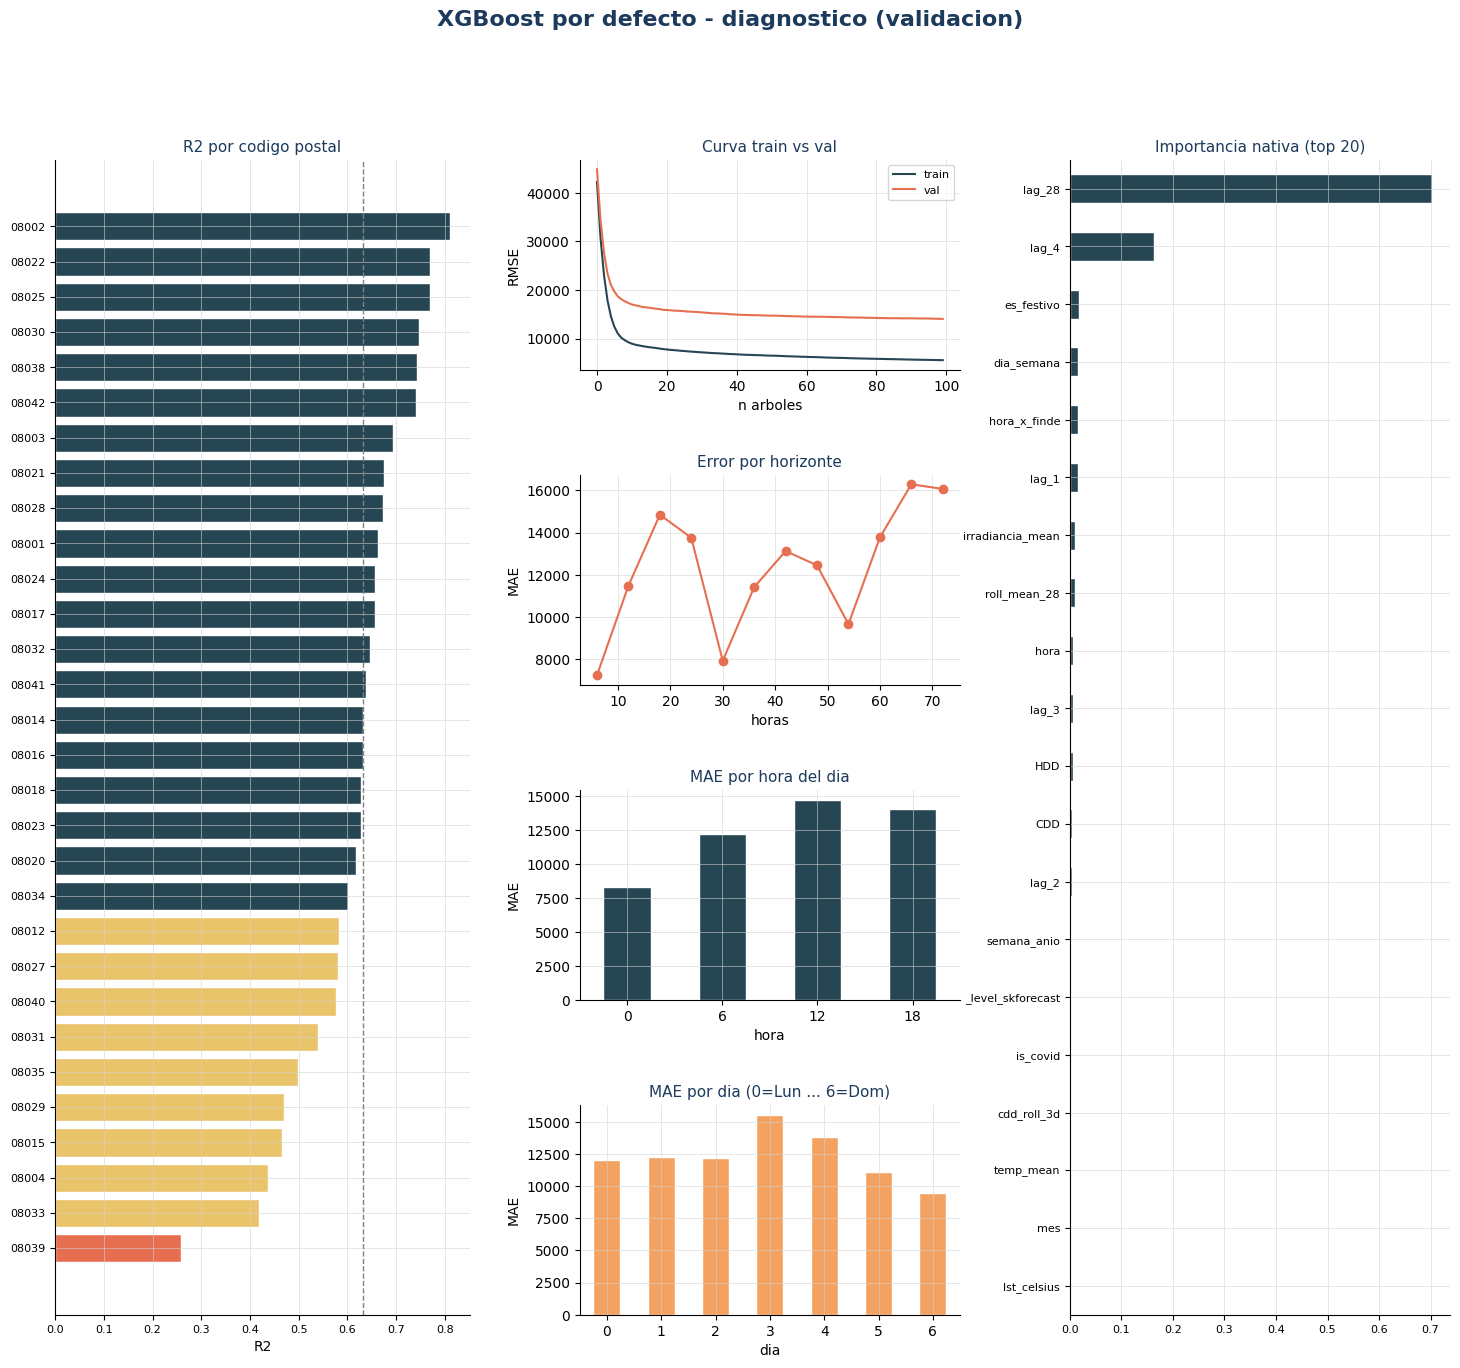

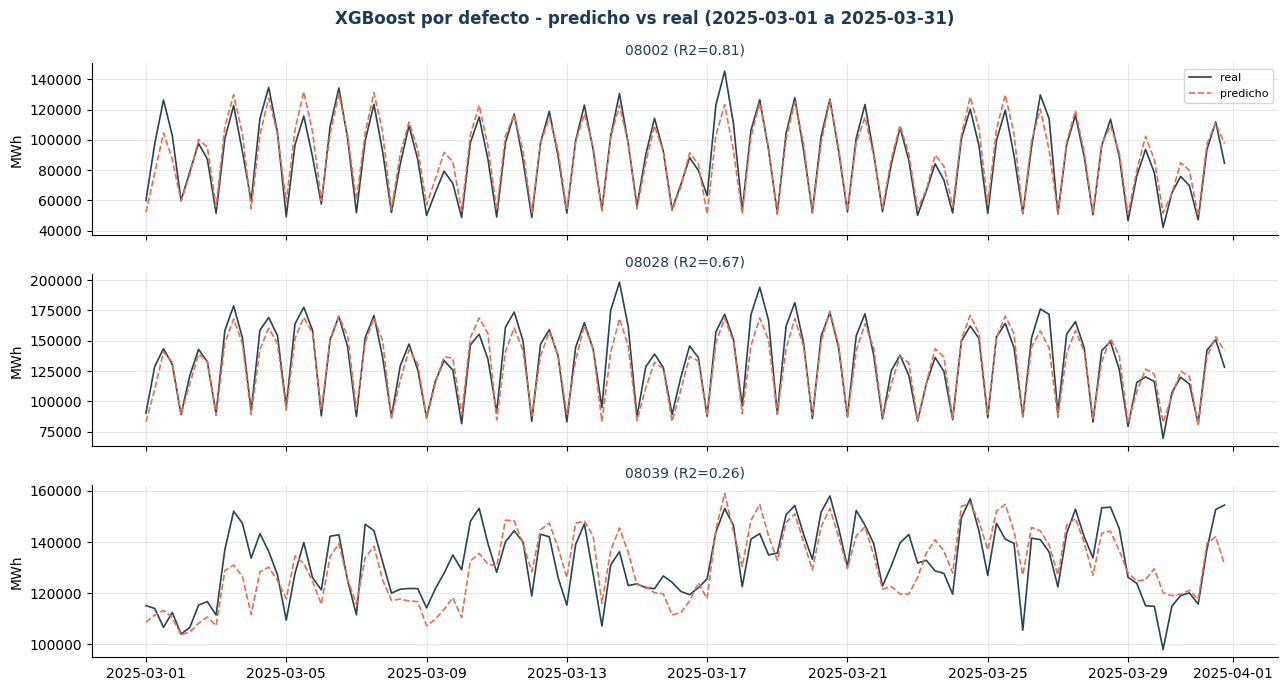

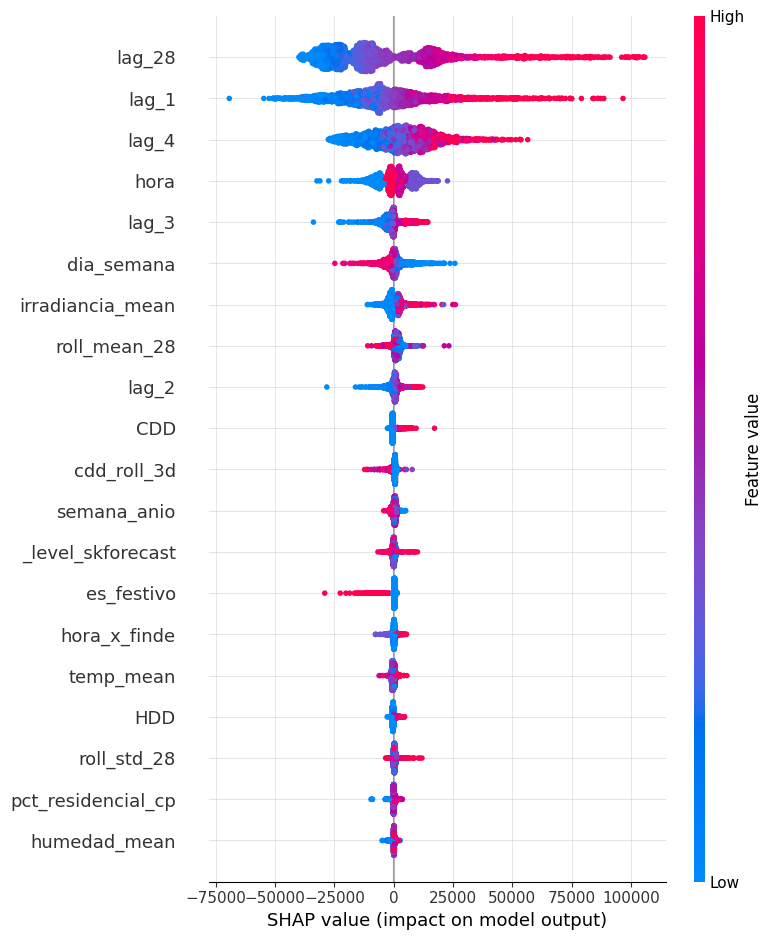

In [ ]:
ml_val = revisar_resultados(predicciones, series_trval, forecaster, exog_trval,
                            nombre='XGBoost por defecto',
                            cps_demo=('08002', '08028', '08039'))

### <font color='#C0392B'><b>2.3 Lectura del modelo defecto</b></font>

> A completar tras ejecutar (mismo guion de lectura que el 06, para comparar XGBoost vs LightGBM):

 - ¿Manda la autorregresión? Mirar si `lag_1`, `lag_4` (24h) y `lag_28` (semanal) lideran SHAP e importancia, igual que en LightGBM.
 - ¿El barrio importa? Ver si `_level_skforecast` (la identidad del CP) aparece alto -> el modelo global aprende las diferencias entre barrios.
 - Calendario vs clima: peso de `hora`/`dia_semana` frente a `irradiancia`/`temp_mean`/`CDD`.
 - Candidatas a poda: variables que quedan abajo en SHAP (el barrio ya las absorbe).
 - Curva train vs val: ¿se separan las líneas? -> overfitting; ¿dónde se aplana el val? -> margen para tuning.
 - Error por horizonte: debería crecer de 6h a 72h (predecir más lejos cuesta más).
 - Cuándo falla: bloque de mediodía (12:00) y días entre semana suelen ser los más difíciles.
 - Comparar el R² mediana/media con el LightGBM por defecto del 06 (se espera algo muy parecido).

---
# <font color='#1B3A5C'>  **3. Control de overfitting: backtest 2024 vs validación** </font>

>  Medimos el modelo base a 72h en dos ventanas comparables y calculamos la diferencia relativa de R²

> Si el modelo es bueno de verdad, debería rendir parecido en 2024 y en 2025. 

La idea es:
1. Entreno de 2019 a 2023, valido con 2024
2. Entreno de 2019 a 2024, valido con 2025

- rel_diff = (R²_base_2024 − R²_base_2025) / |R²_base_2024|.

> Ambos R² se miden con el mismo backtest walk-forward a 72h y el rel_diff compara overfitting real, no un artefacto de escala. De aquí sale la decisión sobre qué hacer con el modelo.

In [ ]:
# Control de overfitting del MODELO BASE: dos evaluaciones OUT-OF-SAMPLE al mismo horizonte (72h).
# OJO: ninguna es el error de train. Las dos son backtest fuera de muestra; solo cambia el ANO evaluado.
# r2_base_2025: entrena -> 2024, evalua 2025 (futuro real, ya calculado en 2.1: 'predicciones')
r2_base_2025 = r2_mediano(predicciones, series_trval)

# r2_base_2024: entrena -> 2023, evalua 2024 (ano nuevo pero pegado al train -> "facil"; datos hasta fin 2024)
FIN_2023     = '2023-12-31 18:00:00'
series_2024  = {cp: s.loc[:FIN_TRAIN] for cp, s in series.items()}   # 2019 -> dic 2024 (train + 2024)
exog_2024    = {cp: e.loc[:FIN_TRAIN] for cp, e in exog.items()}
pred_2024    = backtest_periodo(forecaster, series_2024, exog_2024, fin_entreno=FIN_2023)
r2_base_2024 = r2_mediano(pred_2024, series_2024)

rel_diff = (r2_base_2024 - r2_base_2025) / abs(r2_base_2024)
print(f"R2 base 2024 (cercano, entrena->2023): {r2_base_2024:.3f}")
print(f"R2 base 2025 (lejano,  entrena->2024): {r2_base_2025:.3f}")
print(f"rel_diff                             : {rel_diff:.3f}  ->  "
      f"{'OK, sin overfitting (<=0.10)' if rel_diff <= 0.10 else 'OJO: > 0.10 (overfitting)'}")

print()
elapsed = time.time() - start_time
print(f"Tiempo de ejecucion: {elapsed/60:.1f} min")


### <font color='#C0392B'><b>3.1 Punto de decisión</b></font>

> Con el R²_base_2025 (calidad real fuera de muestra) y el rel_diff (overfitting) del modelo base
> sobre la mesa, aquí se decide el siguiente paso.

**Lectura del modelo base (XGBoost por defecto, backtest 72h):**

- **R²_base_2024:** 0,749 — predicción de 2024 (año nuevo pero pegado al train → "fácil").
- **R²_base_2025:** 0,632 — predicción de 2025 (futuro real, ventana lejana).
- **rel_diff = 0,155** → por encima del umbral de José (0,10): **hay overfitting**.

**Diagnóstico.** El modelo cae de 0,749 (2024) a 0,632 (2025): un `rel_diff` de 0,155, claramente sobre
el umbral de 0,10. El XGBoost sin regularizar se ajusta de más al train y generaliza peor de lo aceptable,
así que **no se lleva a test tal cual**.

**Decisión → regularizar con tuning.** Mismo camino que en el 06: optimizar hiperparámetros penalizando la
complejidad (`reg_alpha`, `reg_lambda`), bajando `max_depth` y `learning_rate`, para recortar el rel_diff
por debajo de 0,10 sin sacrificar R²_base_2025. Solo después de eso tiene sentido el backtest final en test.

**Comparación con LightGBM (06).** Sitúa el punto de partida, con un matiz importante: el 06 mide el rel_diff
sobre el modelo **ya tuneado**, no sobre el de por defecto.

- LightGBM **tuneado**: R²(2025) ≈ 0,69 · rel_diff ≈ 0,10 (0,08 con escalado de series).
- XGBoost **por defecto**: R²_base_2025 0,632 · rel_diff 0,155.

Es decir, XGBoost arranca peor y con más overfitting que el LightGBM *después* de optimizar — esperable,
porque comparamos un modelo crudo contra uno ya afinado. La hipótesis es que el tuning del XGBoost lo acerque
a las cifras del 06; ahí se verá si iguala o supera a LightGBM en igualdad de condiciones.